# Chimera on real fraud - baselines + the closed loop on public data

This notebook grounds Chimera on a **real public benchmark** - the ULB credit-card fraud dataset (284,807 genuine transactions, 492 fraud). It runs standard baselines against Chimera's two-channel ensemble, then applies the **red-team/blue-team loop to real fraud**: perturbing real fraud to evade the model, then retraining to recover. This shows the methodology is not tied to our synthetic simulator.

**To run it, either** (a) add the Kaggle dataset **`mlg-ulb/creditcardfraud`** via *Add Input* - the code reads it directly and runs offline; **or** (b) enable **Internet** in the notebook settings and it fetches the same data from OpenML. Both give identical numbers.

Repo: https://github.com/dhruv-decoder/chimera

In [1]:
!git clone -q https://github.com/dhruv-decoder/chimera.git
%cd chimera
!pip -q install -e "backend[dev]"

### Baselines vs Chimera, and the loop on real data
Runs Logistic Regression, Random Forest, XGBoost (pre-installed on Kaggle) and LightGBM against Chimera's two-channel ensemble, then the evasion/retrain loop on real fraud.

In [2]:
!cd backend && python scripts/benchmark_baselines.py

───────────────── Baselines + closed loop on REAL fraud (ULB) ──────────────────
   Baselines on real ULB fraud (held-out)   
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ model                 ┃ ROC-AUC ┃ PR-AUC ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│ Logistic Regression   │ 0.9696  │ 0.7037 │
│ Random Forest         │ 0.9399  │ 0.8152 │
│ XGBoost               │ 0.9686  │ 0.8422 │
│ LightGBM              │ 0.9502  │ 0.8079 │
│ Chimera (two-channel) │ 0.9508  │ 0.7834 │
└───────────────────────┴─────────┴────────┘
Closed loop on REAL data: baseline 84% -> evasion 59% -> retrained 100%
Saved -> benchmark_report.json


Baselines on real ULB fraud (held-out):
  Logistic Regression      ROC 0.9696  PR-AUC 0.7037
  Random Forest            ROC 0.9399  PR-AUC 0.8152
  XGBoost                  ROC 0.9686  PR-AUC 0.8422
  LightGBM                 ROC 0.9502  PR-AUC 0.8079
  Chimera (two-channel)    ROC 0.9508  PR-AUC 0.7834

Closed loop on REAL data: baseline 84% -> under evasion 59% -> after retrain 100%


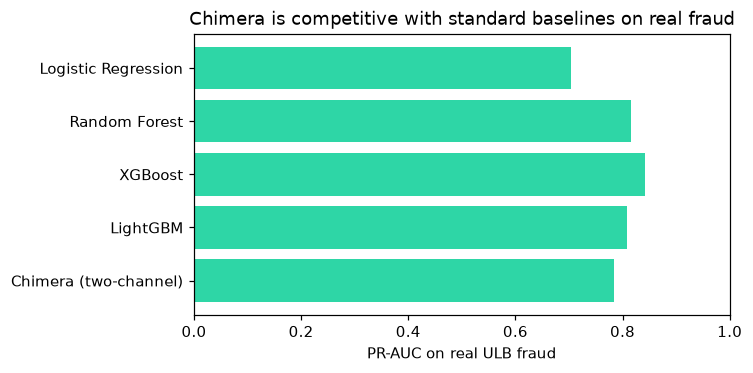

In [3]:
import json, matplotlib.pyplot as plt
r = json.load(open('data/artifacts/benchmark_report.json'))
print('Baselines on real ULB fraud (held-out):')
for k, v in r['baselines'].items():
    print(f"  {k:24s} ROC {v['roc_auc']:.4f}  PR-AUC {v['pr_auc']:.4f}")
cl = r['closed_loop_on_real']
print(f"\nClosed loop on REAL data: baseline {cl['baseline_recall']*100:.0f}%"
      f" -> under evasion {cl['under_evasion']*100:.0f}% -> after retrain {cl['after_retrain']*100:.0f}%")
names = list(r['baselines']); pr = [r['baselines'][n]['pr_auc'] for n in names]
plt.figure(figsize=(7,3.5)); plt.barh(names, pr, color='#2ed6a6')
plt.xlabel('PR-AUC on real ULB fraud'); plt.xlim(0,1); plt.title('Chimera is competitive with standard baselines on real fraud')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

### Takeaway - why this framing matters

**The novelty is the loop, not a leaderboard delta.** A better static PR-AUC on a fixed 2013 benchmark is *not* what defends against GenAI-era fraud, because that fraud changes shape faster than any fixed model is retrained. So Chimera's contribution is deliberately a different axis:

1. **A closed red-team/blue-team loop that adapts.** On this *same real dataset*, an adversary perturbs real fraud toward the legitimate distribution and recall collapses 84% -> 59%; retraining on those evasive samples recovers it to 100%. A static classifier - however well it scores here - cannot do that, because it never sees the evasion.
2. **A novelty channel + agent-identity features for *unseen* vectors.** The leave-one-vector-out study (see `reproduce_chimera.ipynb`) catches a delegated-token agent-hijack the model was never trained on: supervised 15% -> 100%. No amount of baseline PR-AUC captures this.
3. **Agentic-commerce identity abuse as a first-class 2026 vector** - grounded in Mastercard Agent Pay and Visa's Trusted Agent Protocol, which did not exist a year ago.

The baseline table above is therefore a **reliability floor, not the headline**: it proves the detector is a *credible* fraud classifier on real data (competitive with XGBoost / Random Forest / LightGBM, no dataset-specific tuning), so the loop is built on a sound foundation rather than a toy. The parity is the evidence we are honest and grounded; the *loop, the novelty channel, and the agentic-identity defence* are the evidence we are novel.